### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

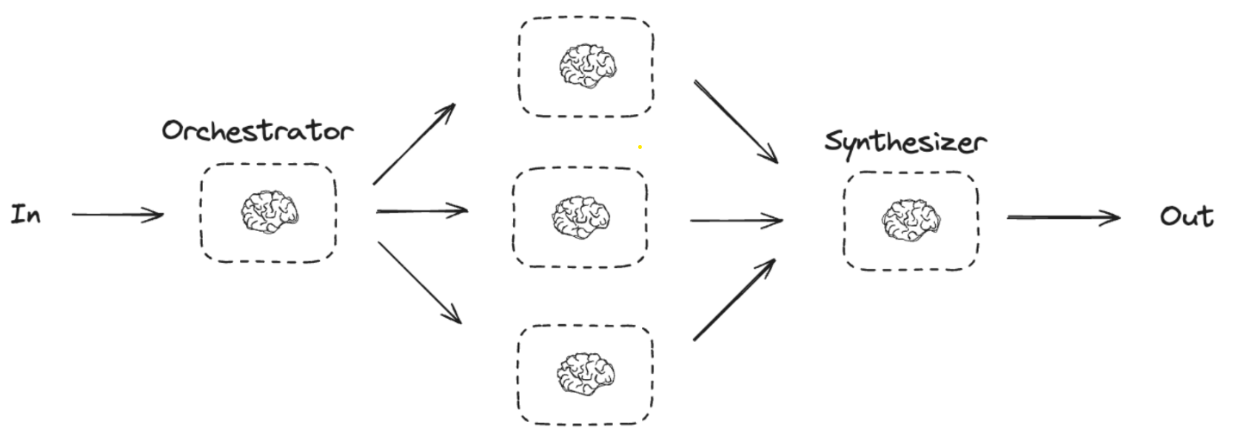

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="qwen/qwen3.8-27b", max_tokens=300)
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.019907115, 'completion_tokens_details': None, 'prompt_time': 0.000664901, 'prompt_tokens_details': None, 'queue_time': 0.021982338, 'total_time': 0.020572016}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_57c7e760a9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a11981-dc9c-7542-b069-5558a19650b3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

In [10]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

Here is a detailed breakdown of how these schema and state definitions tie together the Orchestrator-Worker architecture in LangGraph.

### Pydantic Structured Output Schemas (Section & Sections)

Section: A Pydantic model defining what a single report section looks like (its name and detailed description).

Sections: A container Pydantic model holding a list of Section objects (sections: List[Section]).

llm.with_structured_output(Sections): Forces the LLM provider (via function calling or JSON mode) to respond strictly following the Sections schema rather than returning raw text. When planner.invoke(...) is executed, it returns a strongly typed Sections object containing a validated list of Section instances.

In [11]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

#### Global Graph State (State)

This represents the global memory shared across the entire workflow execution:

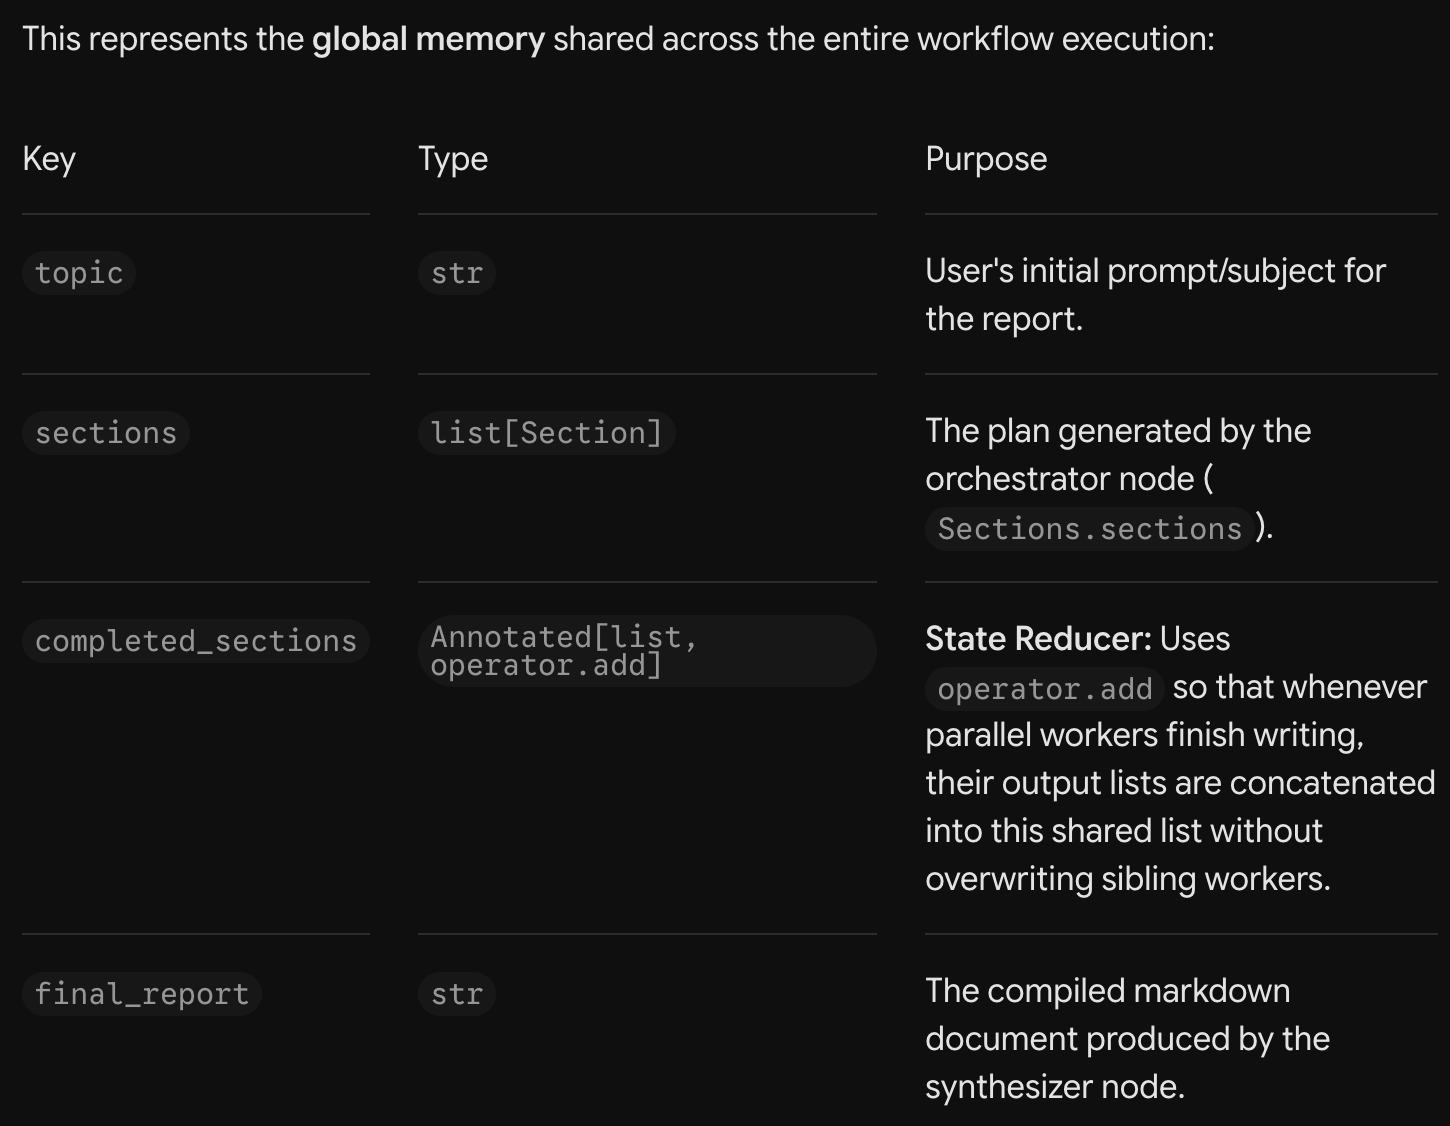

#### Isolated Worker State (WorkerState)

When using LangGraph's Send() API to kick off parallel jobs, each worker node receives its own private input payload matching WorkerState:

section: Section: The specific sub-task payload dispatched by the Send("llm_call", {"section": s}) routing function.

completed_sections: Annotated[list, operator.add]: Allows the worker's output dictionary {"completed_sections": [section_content]} to map seamlessly back into the global state's completed_sections list upon completion.

Complete Execution Flow
1. Input: State(topic="Quantum Computing")
      │
      ▼
2. orchestrator node
   └─► planner.invoke(...) ──► Returns Sections(sections=[Section1, Section2, Section3])
   └─► Updates State: {"sections": [Section1, Section2, Section3]}
      │
      ▼
3. assign_workers routing (Send API)
   └─► Returns [Send("llm_call", {"section": S1}), Send("llm_call", {"section": S2}), ...]
      │
      ├───────────────────────┼───────────────────────┐
      ▼                       ▼                       ▼
   Worker 1                Worker 2                Worker 3
   WorkerState(S1)         WorkerState(S2)         WorkerState(S3)
   Returns {"completed_sections": [Text1]}  {"completed_sections": [Text2]}  {"completed_sections": [Text3]}
      │                       │                       │
      └───────────────────────┼───────────────────────┘
                              │
                              ▼ (operator.add merges worker outputs)
4. State.completed_sections = [Text1, Text2, Text3]
      │
      ▼
5. synthesizer node
   └─► Joins completed_sections into final_report string


### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

This code snippet implements the Orchestrator-Worker pattern in LangGraph. In this architecture, a central manager (the orchestrator) breaks down a large task into dynamic sub-tasks, distributes them to parallel worker nodes using dynamic fan-out, and aggregates the results in a synthesizer node.

#### Pattern Architectural Overview
                        ┌──────────────────┐
                        │   orchestrator   │
                        └────────┬─────────┘
                                 │
                   assign_workers (Send API)
                    ┌────────────┼────────────┐
                    ▼            ▼            ▼
               ┌─────────┐  ┌─────────┐  ┌─────────┐
               │llm_call │  │llm_call │  │llm_call │ (Parallel Workers)
               └────┬────┘  └────┬────┘  └────┬────┘
                    └────────────┼────────────┘
                                 ▼
                        ┌──────────────────┐
                        │   synthesizer    │
                        └──────────────────┘

#### Detailed Component Breakdown

##### 1. orchestrator(state: State) — The Manager Node

Purpose: Takes the high-level input topic and breaks it down into a structured list of report sections.

How it works:

Uses a structured output LLM runner (planner, typically configured with .with_structured_output()) to return a Pydantic model containing a list of sections.

Extracts report_sections.sections, where each element is an object with attributes like name and description.

Returns {"sections": ...}, updating the global graph state key sections.

##### 2. assign_workers(state: State) — Dynamic Fan-Out Router (The Send API)

Purpose: Dynamically spawns parallel worker executions based on the number of sections generated by the orchestrator.

How Send("node_name", arg) works:

Instead of returning a single node string name (like standard conditional edges), returning a list of Send() objects triggers map-reduce / dynamic fan-out execution.

For every section s in state["sections"], LangGraph schedules an independent execution instance of the "llm_call" node.

Each worker receives its own localized state subset: {"section": s} matching the WorkerState schema.

Parallel Execution: All created worker instances execute concurrently across available worker threads or async loops.

##### 3. llm_call(state: WorkerState) — The Worker Node

Purpose: Executes a single sub-task isolated from the other workers—drafting a single markdown section.

How it works:

Takes state['section'] (passed from the Send payload).

Calls llm.invoke(...) to generate the markdown text for that specific section without preamble.

Returns {"completed_sections": [section.content]}.

State Reduction: In your main State schema, completed_sections must be defined using an additive reducer (like Annotated[list[str], operator.add] or add_messages). This ensures that as each parallel worker finishes, its output list is appended to the shared completed_sections list without overwriting parallel sibling workers.

##### 4. synthesizer(state: State) — The Aggregator / Reducer Node

Purpose: Waits for all parallel worker nodes to finish execution (fan-in) and compiles their outputs into a unified final deliverable.

How it works:

Reads the aggregated completed_sections array from state.

Joins all markdown sections together separated by a horizontal rule (---).

Returns {"final_report": ...}, completing the workflow.

In [12]:
from langgraph.types import Send

# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[list, operator.add]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [13]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)
    return {"sections": report_sections.sections}

def worker_llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create worker_llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("worker_llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


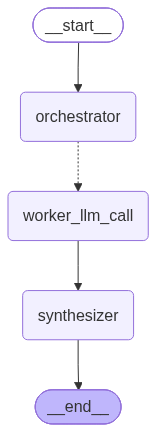

In [14]:
# Build workflow


from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("worker_llm_call", worker_llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["worker_llm_call"]
)
orchestrator_worker_builder.add_edge("worker_llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [15]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a simple report on Cats"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction to Cats', description='An introduction to cats, covering their history as domesticated animals, their origin from the African wildcat, and their role in human society throughout history.'), Section(name='Physical and Behavioral Characteristics', description='A look at the physical and behavioral characteristics of cats, including their size, coat types, hunting instincts, communication methods, and unique traits like night vision and flexible bodies.'), Section(name='Popular Cat Breeds', description='An overview of the major cat breeds, from common domestic shorthairs to popular breeds like Persians, Siamese, Maine Coons, and Sphynx, highlighting their distinctive features and temperaments.'), Section(name='Cat Care and Ownership', description='Guidance on proper cat care, including nutrition and feeding, grooming needs, exercise and play, veterinary checkups, and creating a safe and stimulating home environment.'), Section(name='Be

# Introduction to Cats

Domestic cats (*Felis catus*) represent one of humanity’s oldest and most enduring companions, with a domestication history that spans approximately 9,000 to 10,000 years. Unlike dogs, which were domesticated primarily for their utility in hunting and herding, cats are believed to have initiated a mutualistic relationship with early agricultural societies. As humans transitioned from nomadic hunter-gatherers to settled farmers in the Fertile Crescent, grain stores attracted rodents, which in turn attracted the ancestors of the modern house cat. This symbiotic dynamic likely drew cats into human settlements, marking the beginning of their integration into domestic life.

Genetic and archaeological evidence points to the **African wildcat** (*Felis lybica*) as the primary ancestor of the domestic cat, specifically the subspecies *Felis lybica lybica* found in the Near East. Over millennia, selective breeding and natural selection have produced the vast array of breeds, coat patterns, and temperaments seen today. While the precise timeline of their spread remains a subject of ongoing research, it is clear that cats traveled alongside human trade routes, eventually becoming established across Europe, Asia, and the Americas.

Throughout history, cats have occupied a unique and often revered position in human society. In ancient Egypt, they were not merely pest controllers but were associated with the goddess Bastet, protecting homes and granaries while symbolizing fertility and domesticity

---

# Physical and Behavioral Characteristics

Cats (*Felis catus*) are small, mandatory carnivorous mammals whose physical adaptations are finely tuned for solitary hunting and agility. Their morphology and behavior reflect an evolutionary history optimized for stealth, precision, and survival across diverse environments.

## Size and Body Structure
Cats vary significantly in size depending on breed and individual genetics, with adult body weights typically ranging from 4 to 12 pounds (1.8 to 5.4 kg). Despite their compact frame, cats possess a high muscle-to-bone ratio, granting them explosive power. Their skeletal structure is notably flexible, particularly the spine, which allows for:
*   **Extreme Flexibility:** The ability to twist their bodies mid-air to land on their feet (the "righting reflex").
*   **Agility:** Rapid changes in direction and acceleration without the need for a long run-up.
*   **Compact Form:** A low center of gravity that aids in balance during high-speed chases or climbs.

## Coat Types and Grooming
Feline coats are categorized by length and texture, serving functions ranging from thermoregulation to protection.
*   **Short-Haired:** Dense undercoat with a sleek outer layer, ideal for shedding and water resistance.
*   **Long-Haired:** Longer guard hairs with a softer undercoat, providing insulation but requiring more maintenance to prevent matting.
*   **Hairless:** Such as the S

---

# Popular Cat Breeds

Cats are generally categorized into **Domestic Shorthairs (DSH)**, **Domestic Longhairs (DLH)**, and specific **Breed Standards**. While the majority of cats worldwide are mixed-breed DSHs, recognized breeds offer distinct physical traits and behavioral profiles that appeal to different lifestyles.

## Domestic Shorthairs (DSH)
The "moggie" or common house cat is the most prevalent feline in the world.
*   **Distinctive Features:** A vast array of coat patterns (tabby, calico, tortoiseshell, solid) and colors. They typically possess a short, dense coat and robust build.
*   **Temperament:** Highly adaptable and independent. While individual personalities vary widely, DSHs are generally affectionate, playful, and intelligent. They thrive in both urban apartments and rural homes.

## Persian
Perhaps the most recognizable long-haired breed, the Persian is known for its plush appearance and calm demeanor.
*   **Distinctive Features:** A round head, short muzzle (brachycephalic), large round eyes, and a dense, long double coat that requires daily grooming to prevent matting.
*   **Temperament:** Quiet and gentle Persians are ideal for low-activity households. They are not lap cats by nature but enjoy sitting near their owners. Their calm disposition makes them well-suited for families with other pets.

##

---

# Cat Care and Ownership

Proper cat care is essential for ensuring the longevity, health, and well-being of your feline companion. This section outlines the fundamental aspects of cat ownership, covering nutritional requirements, hygiene, physical activity, medical maintenance, and environmental enrichment.

### Nutrition and Feeding

A balanced diet is the cornerstone of feline health. Cats are obligate carnivores, meaning their physiology is specifically adapted to digest animal protein.

*   **Dietary Composition**: High-quality commercial cat foods should be the primary source of nutrition. Look for products that list a named meat source (e.g., chicken, turkey, salmon) as the first ingredient. Avoid generic terms like "meat by-products" or "animal digest."
*   **Feeding Schedule**:
    *   **Adult Cats**: Can be fed twice daily or allowed free access to dry food if they maintain a healthy weight.
    *   **Kittens**: Require frequent, small meals (3-4 times daily) to support rapid growth.
    *   **Seniors**: May benefit from smaller, more frequent meals to aid digestion.
*   **Hydration**: Cats have a low thirst drive and are prone to urinary tract issues. Encourage water intake by providing fresh water in multiple locations, using a cat water fountain, or incorporating wet food into their diet.
*   **Avoidance**: Never feed cats dog food, as it lacks taurine, an

---

## Benefits of Owning a Cat and Conclusion

Owning a cat provides a multifaceted array of advantages that extend well beyond simple pet ownership. Primarily, cats offer profound **companionship**, providing a quiet yet constant presence that alleviates feelings of loneliness and isolation. Their affectionate behaviors, such as head-bunting and purring, create a secure emotional anchor for their owners.

Beyond emotional support, cats are scientifically proven aids in **stress reduction**. Interactions with cats have been shown to lower cortisol levels and reduce blood pressure, triggering the release of oxytocin and serotonin. This biological response helps mitigate anxiety and promotes a state of calm, making feline companions particularly beneficial for individuals managing high-stress lifestyles.

Furthermore, cats serve a practical role in **pest control**. As natural predators, they are highly effective at managing populations of rodents, insects, and other unwanted pests, offering an eco-friendly alternative to chemical treatments.

In conclusion, the relationship between humans and cats is one of the most enduring partnerships in history. From ancient agricultural settlements to modern urban apartments, cats have consistently adapted to human living spaces, offering a unique blend of independence and intimacy. This bond is not merely transactional but deeply relational, providing owners with health benefits, practical utility, and a timeless sense of connection that continues to enrich human life.

In [ ]:
## Blog Generation